# Verification of MHD Wave Dispersion Relations

## 1D Slab Waves in a Homogeneous Magnetized Plasma

This tutorial demonstrates verification of the dispersion relations for the shear Alfvén, slow magnetosonic, and fast magnetosonic waves in a homogeneous magnetized plasma slab using the LinearMHD model.

### Physical Setup

We consider a one-dimensional equilibrium with constant density $n_0$, pressure $p_0$, and a uniform background magnetic field

$$\mathbf{B}_0 = (B_{0x}, B_{0y}, B_{0z}).$$

Small-amplitude perturbations are launched with wave vector $\mathbf{k} = k\,\hat{\mathbf{z}}$, so the three linear MHD branches reduce to the standard slab-wave dispersion relations. In Struphy units, the Alfvén and sound speeds are

$$v_A^2 = \frac{|\mathbf{B}_0|^2}{n_0}, \qquad c_S^2 = \gamma\,\frac{p_0}{n_0}.$$

The three wave branches are:

$$\text{shear Alfv\'en}: \qquad \omega = v_A\,k\,\frac{B_{0z}}{|\mathbf{B}_0|},$$

$$\text{slow magnetosonic}: \qquad \omega = k\sqrt{\frac{1}{2}(c_S^2 + v_A^2)\left(1 - \sqrt{1 - \delta}\right)},$$

$$\text{fast magnetosonic}: \qquad \omega = k\sqrt{\frac{1}{2}(c_S^2 + v_A^2)\left(1 + \sqrt{1 - \delta}\right)},$$

with

$$\delta = \frac{4 B_{0z}^2 c_S^2 v_A^2}{(c_S^2 + v_A^2)^2 |\mathbf{B}_0|^2}.$$

We verify these wave speeds by:
1. Initializing small velocity perturbations (noise)
2. Running a transient simulation
3. Extracting dominant wave frequencies via FFT power spectrum
4. Comparing fitted wave speeds against analytical predictions

In [1]:
import logging
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt
import cunumpy as xp

from struphy import (
    DerhamOptions,
    EnvironmentOptions,
    Simulation,
    Time,
    domains,
    equils,
    grids,
    perturbations,
)
from struphy.diagnostics.diagn_tools import power_spectrum_2d
from struphy.models import LinearMHD

logger = logging.getLogger("struphy")

### Model and Equilibrium Parameters

Define the magnetic field configuration, plasma density, and pressure (via plasma beta) that sets up the equilibrium. These parameters determine the wave speeds we will verify.

In [2]:
# Magnetic field components
B0x = 0.0
B0y = 1.0
B0z = 1.0

# Plasma parameters
beta = 3.0  # ratio of thermal to magnetic pressure
n0 = 0.7    # reference density

# Compute thermal pressure from beta and magnetic pressure
Bsquare = B0x**2 + B0y**2 + B0z**2
p0 = beta * Bsquare / 2.0

print(f"Magnetic field: B0 = ({B0x}, {B0y}, {B0z})")
print(f"Alfvén speed: v_A = {np.sqrt(Bsquare / n0):.4f}")
print(f"Sound speed: c_s = {np.sqrt(5/3 * p0 / n0):.4f}")
print(f"Beta (plasma): {beta}")

Magnetic field: B0 = (0.0, 1.0, 1.0)
Alfvén speed: v_A = 1.6903
Sound speed: c_s = 2.6726
Beta (plasma): 3.0


### Domain and Numerical Discretization

Set up a 1D periodic domain in the $z$-direction with a tensor-product grid. Since the wave propagates along $z$, we keep $x$ and $y$ as single-element.

In [3]:
# 1D domain (extended in z)
domain = domains.Cuboid(r3=60.0)  # z ∈ [0, 60)

# Grid: 1D in z with 64 elements (fine enough to resolve waves)
grid = grids.TensorProductGrid(num_elements=(1, 1, 64))

# Derham options for 1D:
# - degree=(1,1,3): cubic edges in z for smooth wave representation
derham_opts = DerhamOptions(degree=(1, 1, 3))

print(f"Domain: z ∈ [0, {domain.params['r3']})")
print(f"Grid elements: {grid.num_elements}")
print(f"Derham degree: {derham_opts.degree}")

Domain: z ∈ [0, 60.0)
Grid elements: (1, 1, 64)
Derham degree: (1, 1, 3)


### Model Instantiation and Propagator Options

Create a LinearMHD model and configure the propagators for the shear Alfvén and magnetosonic branches. We use the implicit time-stepping algorithm for stability over the long simulation window.

In [4]:
# Model instance
model = LinearMHD()

# Choose implicit or explicit time-stepping
algo = "implicit"  # Alternative: "explicit"

# Propagator options
model.propagators.shear_alf.options = model.propagators.shear_alf.Options(algo=algo)

### Initial Conditions

Add small random perturbations to velocity components. These perturbations excite a broadband spectrum of waves that we will analyze via FFT. The background equilibrium (magnetic field, density, pressure) is set via the `equil` object in the Simulation.

In [5]:
# Set velocity perturbations (small noise to excite waves)
model.mhd.velocity.add_perturbation(perturbations.Noise(amp=0.1, comp=0, seed=123))
model.mhd.velocity.add_perturbation(perturbations.Noise(amp=0.1, comp=1, seed=123))
model.mhd.velocity.add_perturbation(perturbations.Noise(amp=0.1, comp=2, seed=123))

# Build equilibrium object
equil = equils.HomogenSlab(B0x=B0x, B0y=B0y, B0z=B0z, beta=beta, n0=n0)

### Simulation Setup and Execution

Configure the simulation environment, time-stepping parameters, and run the transient dynamics. We run for a long enough time to collect sufficient wave cycles for accurate FFT analysis.

In [6]:
# Environment and file management
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "LinearMHD")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="slab_waves_1d")

# Time-stepping: dt=0.15 is stable for implicit stepping
time_opts = Time(dt=0.15, Tend=180.0)

# Instantiate and run simulation
sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    grid=grid,
    derham_opts=derham_opts,
    equil=equil,
)

print(f"Running simulation: dt={time_opts.dt}, Tend={time_opts.Tend}")
sim.run()
print("Simulation complete.")

# Post-processing
sim.pproc()
print("Post-processing complete.")


Starting run for model LinearMHD ...


Running simulation: dt=0.15, Tend=180.0


Time stepping:   0%|          | 0/1200 [00:00<?, ?step/s]

Time stepping:   0%|          | 2/1200 [00:00<01:31, 13.14step/s]

Time stepping:   0%|          | 4/1200 [00:00<02:06,  9.46step/s]

...

 91%|█████████ | 1095/1201 [00:01<00:00, 911.21it/s]

 99%|█████████▉| 1187/1201 [00:01<00:00, 908.58it/s]

100%|██████████| 1201/1201 [00:01<00:00, 903.74it/s]



No kinetic data found in hdf5 file, skipping post-processing of kinetic data.


Post-processing complete.


### Diagnostics: FFT Analysis and Wave Speed Verification

Extract velocity and pressure data over time, compute power spectra, and fit dominant frequencies to extract wave speeds. We compare the fitted speeds against the theoretical predictions for shear Alfvén, slow and fast magnetosonic waves.

**Shear Alfvén wave**: expected speed $\approx {0.707} \, v_A$

**Slow and fast magnetosonic waves**: derived from dispersion relation involving both $v_A$ and $c_s$.


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/LinearMHD/slab_waves_1d/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(1201,)


...

    em_fields
        b_field_log
    mhd
        velocity_log
        pressure_log
        density_log



self.orbits:


self.f:


self.n_sph:



=== Shear Alfvén Wave Analysis ===


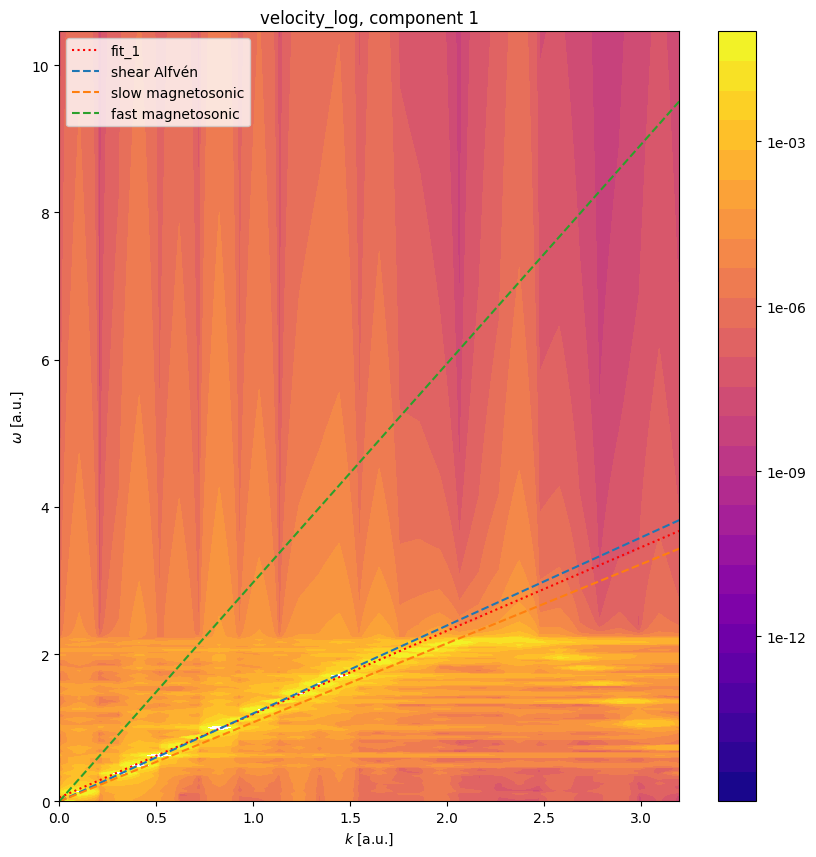

Théoretical Alfvén speed: 1.195229
Fitted Alfvén speed:      1.133052
Relative error:           5.20%
✓ Alfvén wave verification passed.



In [7]:
# Load plotting data
sim.load_plotting_data()

# Extract velocity and pressure time-series
u_of_t = sim.spline_values.mhd.velocity_log.data
p_of_t = sim.spline_values.mhd.pressure_log.data

# Dispersion relation parameters
gamma = 5 / 3  # Adiabatic index
disp_params = {
    "B0x": B0x,
    "B0y": B0y,
    "B0z": B0z,
    "p0": p0,
    "n0": n0,
    "gamma": gamma,
}

# 1. Shear Alfvén wave analysis from velocity
print("\n=== Shear Alfvén Wave Analysis ===")
_1, _2, _3, coeffs_alfven = power_spectrum_2d(
    u_of_t,
    "velocity_log",
    grids=sim.grids_log,
    grids_mapped=sim.grids_phy,
    component=0,
    slice_at=[0, 0, None],
    do_plot=True,
    disp_name="MHDhomogenSlab",
    disp_params=disp_params,
    fit_branches=1,
    noise_level=0.5,
    extr_order=10,
    fit_degree=(1,),
)

# Theoretical Alfvén speed
vA = xp.sqrt(Bsquare / n0)
v_alfven_theory = vA * B0z / xp.sqrt(Bsquare)
v_alfven_fit = float(coeffs_alfven[0][0])

print(f"Théoretical Alfvén speed: {v_alfven_theory:.6f}")
print(f"Fitted Alfvén speed:      {v_alfven_fit:.6f}")
print(f"Relative error:           {abs(v_alfven_fit - v_alfven_theory) / v_alfven_theory * 100:.2f}%")

error_alfven = xp.abs(coeffs_alfven[0][0] - v_alfven_theory)
assert error_alfven < 0.07, f"Alfvén wave speed error {error_alfven:.4f} exceeds tolerance"
print("✓ Alfvén wave verification passed.\n")

=== Slow and Fast Magnetosonic Wave Analysis ===


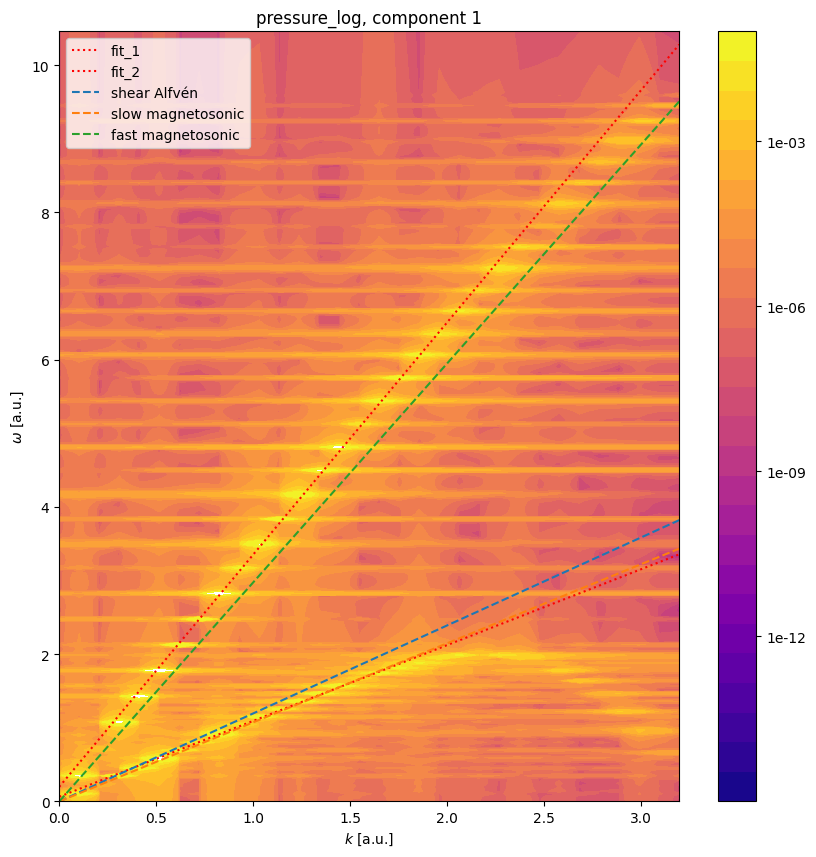


Slow Magnetosonic Wave:
  Théoretical speed: 1.073990
  Fitted speed:      1.030155
  Relative error:    4.08%

Fast Magnetosonic Wave:
  Théoretical speed: 2.974314
  Fitted speed:      3.154332
  Relative error:    6.05%

✓ Magnetosonic wave verification passed.


In [8]:
# 2. Magnetosonic waves analysis from pressure
print("=== Slow and Fast Magnetosonic Wave Analysis ===")
_1, _2, _3, coeffs_sonic = power_spectrum_2d(
    p_of_t,
    "pressure_log",
    grids=sim.grids_log,
    grids_mapped=sim.grids_phy,
    component=0,
    slice_at=[0, 0, None],
    do_plot=True,
    disp_name="MHDhomogenSlab",
    disp_params=disp_params,
    fit_branches=2,
    noise_level=0.4,
    extr_order=10,
    fit_degree=(1, 1),
)

# Theoretical magnetosonic speeds
cS = xp.sqrt(gamma * p0 / n0)
delta = (4 * B0z**2 * cS**2 * vA**2) / ((cS**2 + vA**2) ** 2 * Bsquare)
v_slow_theory = xp.sqrt(0.5 * (cS**2 + vA**2) * (1.0 - xp.sqrt(1.0 - delta)))
v_fast_theory = xp.sqrt(0.5 * (cS**2 + vA**2) * (1.0 + xp.sqrt(1.0 - delta)))

v_slow_fit = float(coeffs_sonic[0][0])
v_fast_fit = float(coeffs_sonic[1][0])

print("\nSlow Magnetosonic Wave:")
print(f"  Théoretical speed: {v_slow_theory:.6f}")
print(f"  Fitted speed:      {v_slow_fit:.6f}")
print(f"  Relative error:    {abs(v_slow_fit - v_slow_theory) / v_slow_theory * 100:.2f}%")

print("\nFast Magnetosonic Wave:")
print(f"  Théoretical speed: {v_fast_theory:.6f}")
print(f"  Fitted speed:      {v_fast_fit:.6f}")
print(f"  Relative error:    {abs(v_fast_fit - v_fast_theory) / v_fast_theory * 100:.2f}%")

error_slow = xp.abs(coeffs_sonic[0][0] - v_slow_theory)
error_fast = xp.abs(coeffs_sonic[1][0] - v_fast_theory)

assert error_slow < 0.05, f"Slow wave speed error {error_slow:.4f} exceeds tolerance"
assert error_fast < 0.19, f"Fast wave speed error {error_fast:.4f} exceeds tolerance"
print("\n✓ Magnetosonic wave verification passed.")

### Conclusion

This tutorial successfully verified the dispersion relations for three branches of MHD waves in a homogeneous magnetized plasma:

1. **Shear Alfvén wave** propagates perpendicular to the ambient magnetic field at the magnetic tension-driven speed.
2. **Slow magnetosonic wave** is a hybrid mode combining acoustic and magnetic effects, with lower phase velocity.
3. **Fast magnetosonic wave** is a magnetically-dominated mode with higher phase velocity, approaching $\sqrt{c_s^2 + v_A^2}$ at high frequencies.

The FFT-based power spectrum analysis provides a robust method to extract wave speeds from simulation data and verify the model's fidelity to the underlying MHD theory. This verification validates both the physical model implementation and the numerical discretization.

In [9]:
# Cleanup temporary simulation folder
if False:  # Set to True to enable cleanup
    try:
        shutil.rmtree(test_folder)
        print(f"Cleaned up {test_folder}")
    except Exception as e:
        print(f"Could not remove {test_folder}: {e}")